### Comparison with RF-based –HP portfolio models.

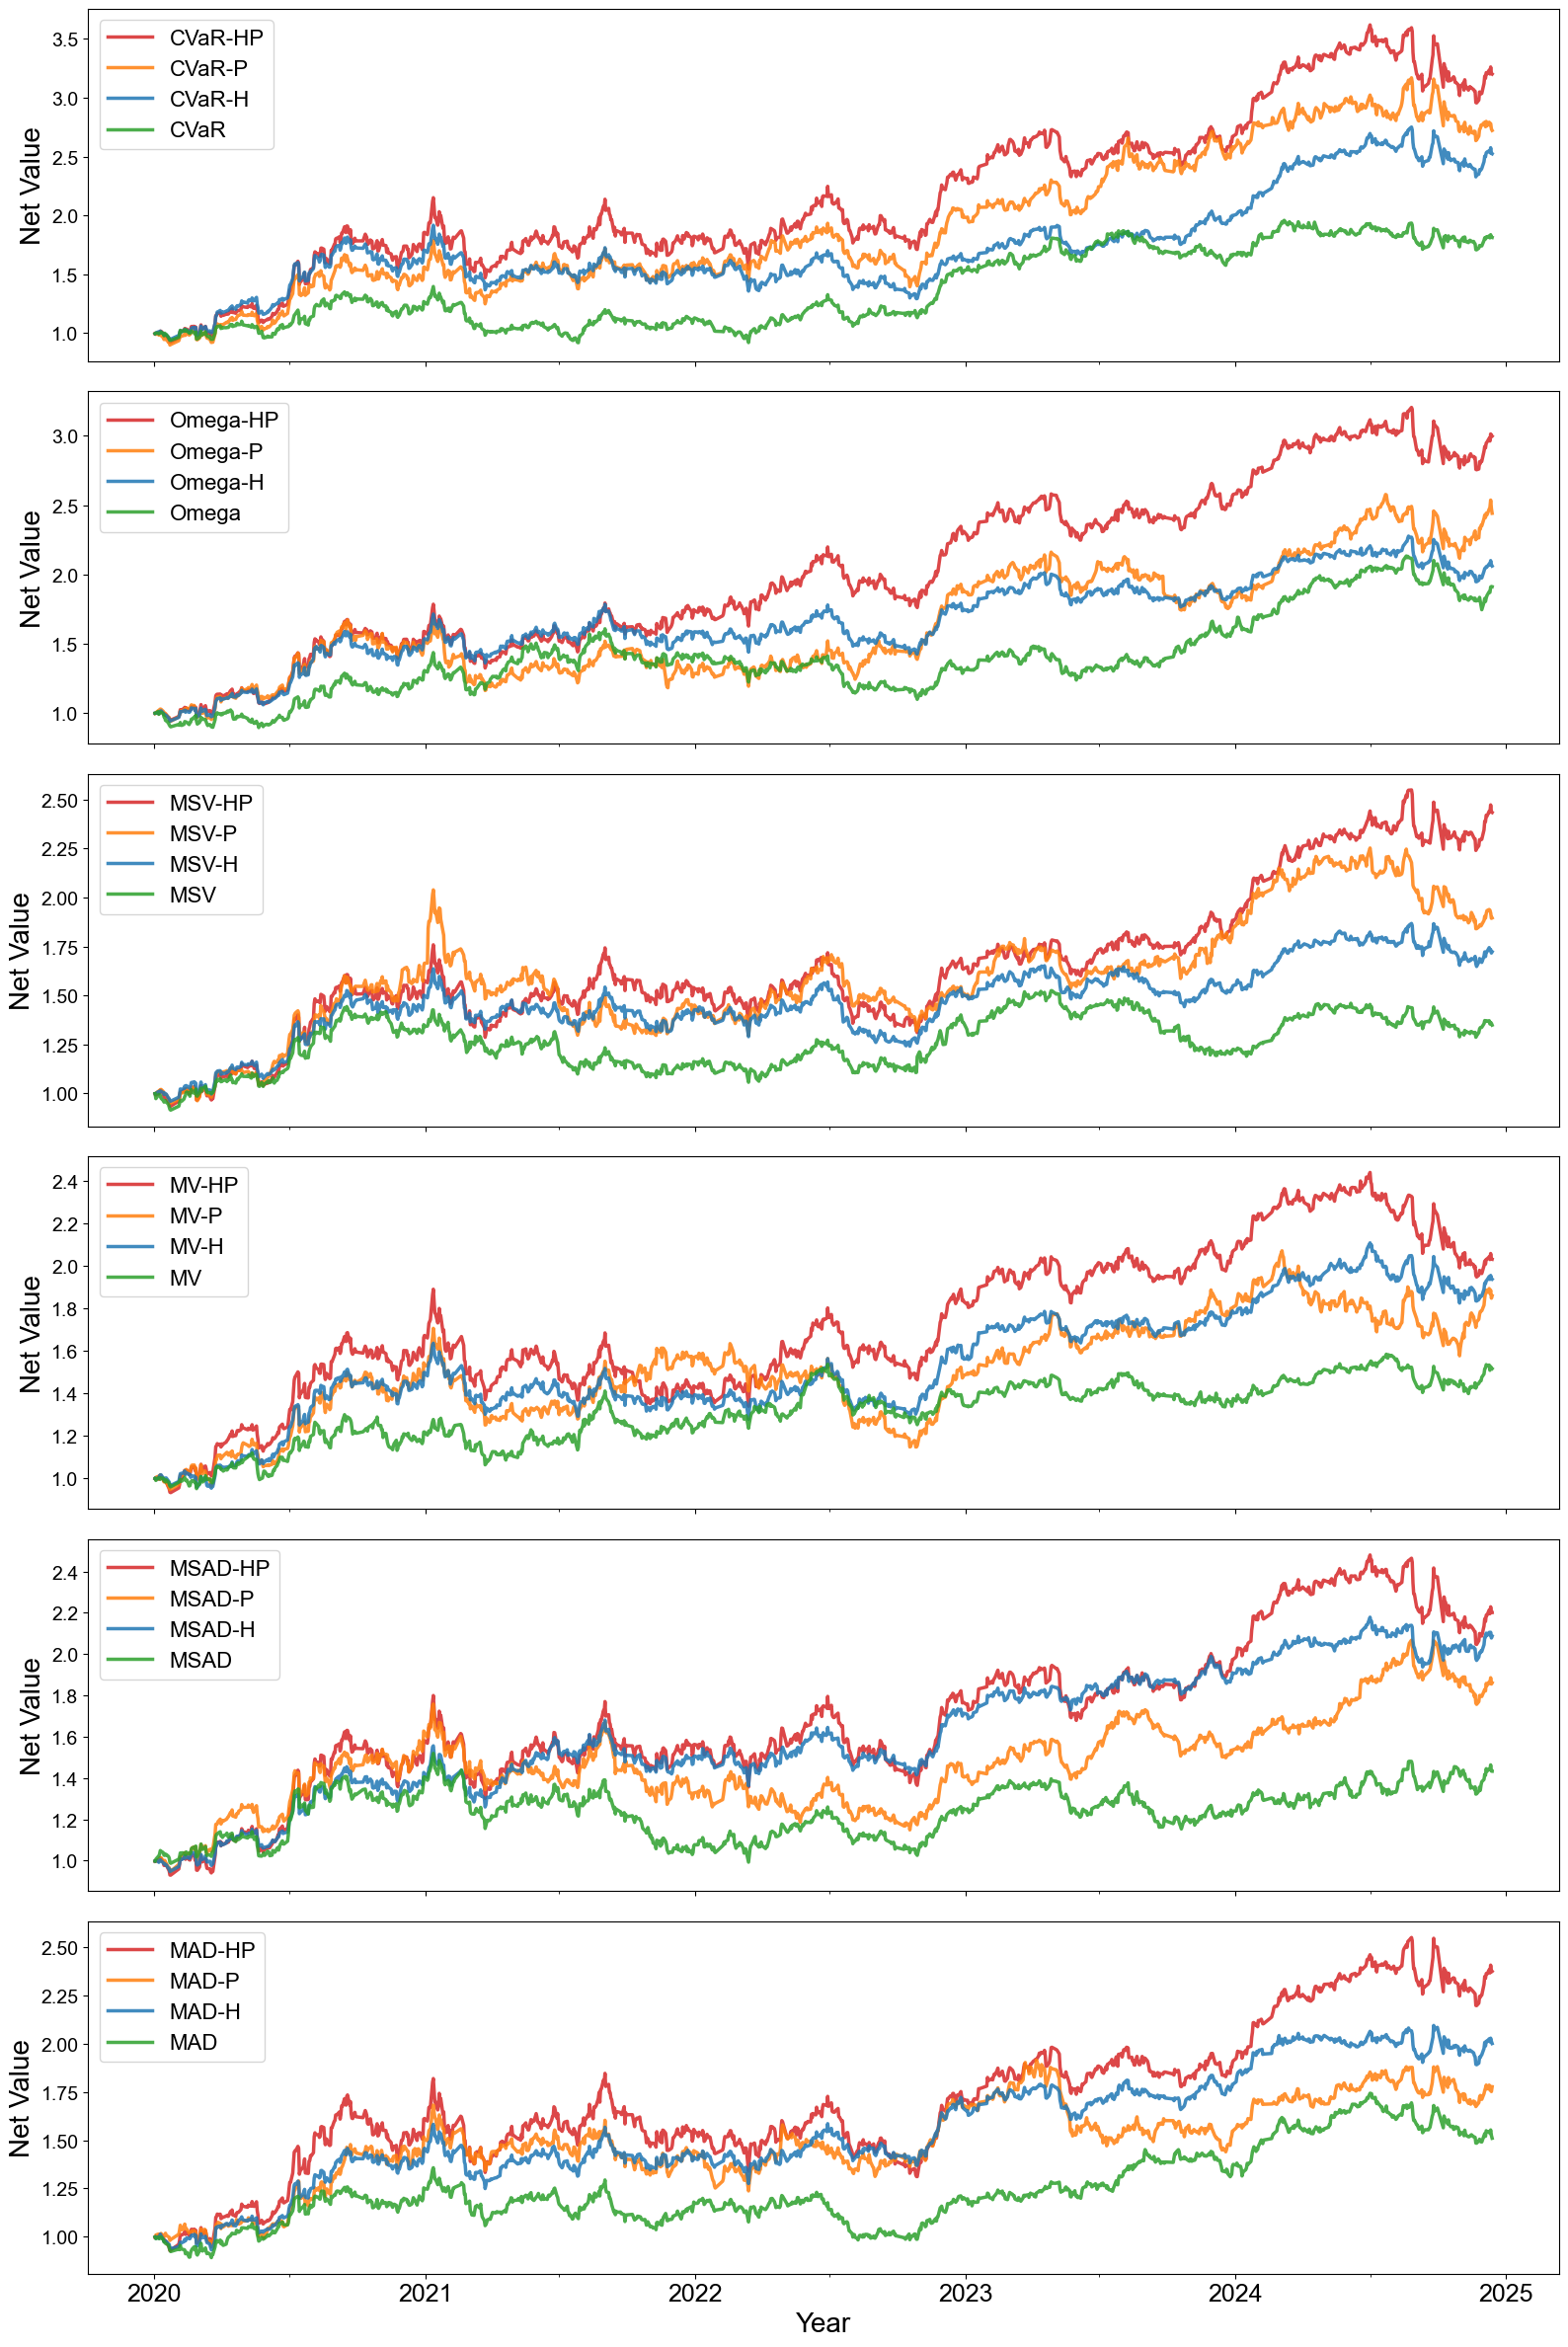

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['font.sans-serif'] = ['Arial']

def read_model_data(model_name):
    filename = f'rf_portfolio_daily_returns.csv'
    df = pd.read_csv(filename)
    
    # 将date列转换为日期格式
    df['date'] = pd.to_datetime(df['date'])

    model_data = {
        'Original_return': df[model_name +'_Original'],
        'HigherMoments_return': df[model_name +'_HigherMoments'],
        'Predictive_return': df[model_name +'_Predictive'],
        'Integrated_return': df[model_name +'_Integrated']
    }

    return df['date'], model_data

def plot_all_models_subplot(all_dates, all_model_data, models_list):
    """
    绘制所有模型的组图,竖着排列
    """
    plt.rcParams.update({'font.size': 14})
    fig, axes = plt.subplots(6, 1, figsize=(16, 24))

    colors = {
        'Original': '#2ca02c',      # 原始绿色
        'HigherMoments': '#1f77b4', # -H蓝色
        'Predictive': '#ff7f0e',    # -P橘色
        'Integrated': '#d62728'     # -HP红色
    }
    
    for i, model_name in enumerate(models_list):
        ax = axes[i]
        dates = all_dates[model_name]
        model_data = all_model_data[model_name]

        original_cumret = (1 + model_data['Original_return']).cumprod()
        higher_cumret = (1 + model_data['HigherMoments_return']).cumprod()
        predictive_cumret = (1 + model_data['Predictive_return']).cumprod()
        integrated_cumret = (1 + model_data['Integrated_return']).cumprod()

        ax.plot(dates, integrated_cumret, 
                label=f'{model_name}-HP', 
                linewidth=2.5, alpha=0.85, color=colors['Integrated'])
        ax.plot(dates, predictive_cumret, 
                label=f'{model_name}-P', 
                linewidth=2.5, alpha=0.85, color=colors['Predictive'])
        ax.plot(dates, higher_cumret, 
                label=f'{model_name}-H', 
                linewidth=2.5, alpha=0.85, color=colors['HigherMoments'])
        ax.plot(dates, original_cumret, 
                label=f'{model_name}', 
                linewidth=2.5, alpha=0.85, color=colors['Original'])

        ax.set_ylabel('Net Value', fontsize=20)
        ax.legend(loc='best', fontsize=16)
        ax.grid(False)

        ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
        ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 7]))

        ax.tick_params(axis='x', labelsize=14)
        ax.tick_params(axis='y', labelsize=14)

        if i == len(models_list) - 1:
            ax.set_xlabel('Year', fontsize=20)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize=18)
        else:
            ax.xaxis.set_major_formatter(mdates.DateFormatter(''))
            plt.setp(ax.xaxis.get_majorticklabels(), visible=False)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # 定义六个模型列表
    models_list = ['CVaR', 'Omega', 'MSV', 'MV', 'MSAD', 'MAD']
    all_model_data = {}
    all_dates = {}
    
    # 读取每个模型的数据
    for model_name in models_list:
        dates, model_data = read_model_data(model_name)
        all_dates[model_name] = dates
        all_model_data[model_name] = model_data
    plot_all_models_subplot(all_dates, all_model_data, models_list)

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

def calculate_portfolio_metrics_with_cost():
    """
    CR: 累计收益率 (Cumulative Return)
    ER: 超额收益率 (Excess Return) - 按照公式 ER = Σ(Rp,t - Rm,t) / T
    SD: 标准差 (Standard Deviation) - 基于月度超额收益率
    MD: 最大回撤 (Maximum Drawdown)
    IR: 信息比率 (Information Ratio) - ER / SD
    VaR: 风险价值 (Value at Risk) - 5%置信水平下的日度VaR
    CVaR: 条件风险价值 (Conditional Value at Risk) - 5%置信水平下的日度CVaR
    TUR: 平均换手率 (Turnover Rate) - 换手率的非零非第一个数据的平均值
    """
    df = pd.read_csv('rf_portfolio_daily_returns.csv')
    df['date'] = pd.to_datetime(df['date'])
    turnover_df = pd.read_csv('rf_portfolio_turnover_transformed.csv')
    turnover_df['date'] = pd.to_datetime(turnover_df['date'])
    
    benchmark_df = pd.read_csv('CSI141每日收益率_2020_2024.csv')
    benchmark_df['date'] = pd.to_datetime(benchmark_df['Date'])

    merged_df = pd.merge(df, benchmark_df, on='date', how='inner')
    merged_df = pd.merge(merged_df, turnover_df, on='date', how='inner')

    model_names =['MV', 'MSV', 'MAD', 'MSAD', 'Omega', 'CVaR']
    versions = ['Original', 'HigherMoments', 'Predictive', 'Integrated']
    
    # 步骤1: 收集投资组合列信息
    portfolio_columns = []
    turnover_columns = []
    
    for model_name in model_names:
        for version in versions:
            col_name = f'{model_name}_{version}'
            full_name = f'{model_name}-{version}'

            if version == 'Original':
                full_name = model_name  # Original版本不显示后缀
            elif version == 'HigherMoments':
                full_name = f'{model_name}-H'
            elif version == 'Predictive':
                full_name = f'{model_name}-P'
            elif version == 'Integrated':
                full_name = f'{model_name}-HP'
            
            if col_name in merged_df.columns:
                portfolio_columns.append((full_name, col_name))

            turnover_col_name = f'{model_name}_{version}_turnover'
            if turnover_col_name in merged_df.columns:
                turnover_columns.append((full_name, turnover_col_name))
    
    # 步骤2: 计算月度超额收益率
    merged_df['year_month'] = merged_df['date'].dt.to_period('M')
    
    # 先计算基准的月度收益率
    benchmark_monthly = merged_df.groupby('year_month')['CSI141_DailyReturn'].apply(
        lambda x: (1 + x).prod() - 1, include_groups=False
    )
    
    # 按月分组计算月度超额收益率
    monthly_excess_returns = {}
    monthly_data_list = []
    
    for full_name, col_name in portfolio_columns:
        # 先分别计算投资组合月度收益率
        portfolio_monthly = merged_df.groupby('year_month')[col_name].apply(
            lambda x: (1 + x).prod() - 1, include_groups=False
        )
        
        # 计算月度超额收益率: 投资组合月度收益率 - 基准月度收益率
        monthly_excess_values = portfolio_monthly - benchmark_monthly
        
        monthly_excess = pd.DataFrame({
            'year_month': monthly_excess_values.index,
            f'{full_name}_monthly_excess': monthly_excess_values.values
        }).reset_index(drop=True)
        
        if len(monthly_data_list) == 0:
            monthly_data_list.append(monthly_excess[['year_month', f'{full_name}_monthly_excess']])
        else:
            monthly_data_list.append(monthly_excess[[f'{full_name}_monthly_excess']])
        
        monthly_excess_returns[full_name] = monthly_excess_values

    if monthly_data_list:
        monthly_df = pd.concat(monthly_data_list, axis=1)
        monthly_df['year_month'] = monthly_df['year_month'].astype(str)
        monthly_df.to_csv('rf_Monthly_Excess_Returns.csv', index=False, encoding='utf-8-sig')
    
    # 步骤3: 计算年度指标
    all_combinations = [full_name for full_name, _ in portfolio_columns]
    
    results = pd.DataFrame(
        index=all_combinations,
        columns=['CR', 'MD', 'ER', 'SD', 'IR', 'VaR', 'CVaR', 'TUR']
    )
    
    for full_name, col_name in portfolio_columns:
        portfolio_returns = merged_df[col_name]
        
        if full_name in monthly_excess_returns:
            monthly_excess = monthly_excess_returns[full_name]
        else:
            continue
        
        # 1. CR: 累计收益率 (Cumulative Return)
        cumulative_return = (1 + portfolio_returns).cumprod().iloc[-1] - 1
        
        # 2. ER: 超额收益率 - 按照公式 ER = Σ(Rp,t - Rm,t) / T
        ER = monthly_excess.mean()
        
        # 3. SD: 标准差 - 基于月度超额收益率的标准差
        SD = monthly_excess.std()
        
        # 4. IR: 信息比率 (Information Ratio) - ER / SD
        if SD != 0:
            IR = ER / SD
        else:
            IR = 0
        
        # 5. VaR(5%): 风险价值 - 基于日度收益率
        VaR = np.percentile(portfolio_returns, 5)
        
        # 6. CVaR(5%): 条件风险价值 - 基于日度收益率
        var_threshold = VaR
        tail_returns = portfolio_returns[portfolio_returns <= var_threshold]
        if len(tail_returns) > 0:
            CVaR = tail_returns.mean()
        else:
            CVaR = VaR
        
        # 7. MD: 最大回撤 (Maximum Drawdown)
        cumulative_returns = (1 + portfolio_returns).cumprod()
        peak = cumulative_returns.expanding().max()
        drawdown = (cumulative_returns - peak) / peak
        max_drawdown = drawdown.min()
        
        # 8. TUR: 平均换手率 (Turnover Rate)
        TUR = 0
        turnover_col_name = f'{col_name}_turnover'
        if turnover_col_name in merged_df.columns:
            turnover_data = merged_df[turnover_col_name].values
            
            mask = np.ones(len(turnover_data), dtype=bool)
            mask[0] = False  # 排除第一个数据点
            mask = mask & (turnover_data != 0)  # 排除零值
            
            # 计算非零非第一个数据的平均值
            if mask.sum() > 0:
                TUR = turnover_data[mask].mean()
            else:
                TUR = 0
        
        results.loc[full_name, 'CR'] = f"{cumulative_return:.6f}"
        results.loc[full_name, 'MD'] = f"{max_drawdown:.6f}"
        results.loc[full_name, 'ER'] = f"{ER:.6f}"
        results.loc[full_name, 'SD'] = f"{SD:.6f}"
        results.loc[full_name, 'IR'] = f"{IR:.6f}"
        results.loc[full_name, 'VaR'] = f"{VaR:.8f}"
        results.loc[full_name, 'CVaR'] = f"{CVaR:.8f}"
        results.loc[full_name, 'TUR'] = f"{TUR:.4f}"
    
    return results, monthly_df

def display_and_save_results_with_cost():
    """
    显示和保存包含成本比率和风险指标的结果
    """

    results_df, monthly_df = calculate_portfolio_metrics_with_cost()

    model_names = ['MV', 'MSV', 'MAD', 'MSAD', 'Omega', 'CVaR']
    version_order = ['-HP']

    print("\n" + "=" * 110)
    print("Portfolio Performance Metrics")
    print("=" * 110)
    
    for model_name in model_names:        
        for version_suffix in version_order:
            if version_suffix == '':
                full_name = model_name
            else:
                full_name = f'{model_name}{version_suffix}'
                
            if full_name in results_df.index:
                row_data = results_df.loc[full_name]
                print(f"{full_name:<10} CR={row_data['CR']:<8} MD={row_data['MD']:<8} ER={row_data['ER']:<8} SD={row_data['SD']:<8} "
                      f"IR={row_data['IR']:<8} VaR={row_data['VaR']:<8} CVaR={row_data['CVaR']:<8} "
                       f"TUR={row_data['TUR']:<8}")

    print("\n" + "=" * 110)

    results_df.to_csv('rf_Portfolio_Metrics_Results_WithRisk.csv', encoding='utf-8-sig')
    return results_df
if __name__ == "__main__":
    results = display_and_save_results_with_cost()


Portfolio Performance Metrics
MV-HP      CR=1.029420 MD=-0.291714 ER=0.008047 SD=0.063682 IR=0.126359 VaR=-0.02258039 CVaR=-0.03397875 TUR=1.3775  
MSV-HP     CR=1.434683 MD=-0.268961 ER=0.011146 SD=0.059673 IR=0.186785 VaR=-0.02461597 CVaR=-0.03558432 TUR=1.4466  
MAD-HP     CR=1.376252 MD=-0.290043 ER=0.011120 SD=0.062937 IR=0.176686 VaR=-0.02557047 CVaR=-0.03862347 TUR=1.2398  
MSAD-HP    CR=1.201029 MD=-0.277065 ER=0.009793 SD=0.062850 IR=0.155814 VaR=-0.02633858 CVaR=-0.03886396 TUR=1.3086  
Omega-HP   CR=1.997902 MD=-0.258147 ER=0.014535 SD=0.061020 IR=0.238195 VaR=-0.02488506 CVaR=-0.03607133 TUR=1.5155  
CVaR-HP    CR=2.200502 MD=-0.316313 ER=0.017018 SD=0.072656 IR=0.234232 VaR=-0.03135704 CVaR=-0.04616426 TUR=1.6256  



### Comparison of return characteristics of LSTM-based –HP models across (1) FI (2) TI (3) Big data.

In [1]:
import pandas as pd
def calculate_portfolio_metrics_with_cost(df,i):

    df['date'] = pd.to_datetime(df['date'])
    benchmark_df = pd.read_csv('CSI141每日收益率_2020_2024.csv')
    benchmark_df['date'] = pd.to_datetime(benchmark_df['Date'])
    
    # 合并数据
    merged_df = pd.merge(df, benchmark_df, on='date', how='inner')

    # 定义模型名称和版本
    model_names =['MV', 'MSV', 'MAD', 'MSAD', 'Omega', 'CVaR']
    versions = ['Original', 'HigherMoments', 'Predictive', 'Integrated'] 
    
    # 步骤1: 收集投资组合列信息
    portfolio_columns = []
    
    for model_name in model_names:
        for version in versions:
            col_name = f'{model_name}_{version}'
            full_name = f'{model_name}-{version}' 

            if version == 'Original':
                full_name = model_name 
            elif version == 'HigherMoments':
                full_name = f'{model_name}-H'
            elif version == 'Predictive':
                full_name = f'{model_name}-P'
            elif version == 'Integrated':
                full_name = f'{model_name}-HP'
            
            if col_name in merged_df.columns:
                portfolio_columns.append((full_name, col_name))
    
    # 步骤2: 计算月度超额收益率 
    merged_df['year_month'] = merged_df['date'].dt.to_period('M')
    
    # 先计算基准的月度收益率
    benchmark_monthly = merged_df.groupby('year_month')['CSI141_DailyReturn'].apply(
        lambda x: (1 + x).prod() - 1, include_groups=False
    )
    
    # 按月分组计算月度超额收益率
    monthly_excess_returns = {}
    monthly_data_list = []
    
    for full_name, col_name in portfolio_columns:
        # 先分别计算投资组合月度收益率
        portfolio_monthly = merged_df.groupby('year_month')[col_name].apply(
            lambda x: (1 + x).prod() - 1, include_groups=False
        )
        
        # 计算月度超额收益率: 投资组合月度收益率 - 基准月度收益率
        monthly_excess_values = portfolio_monthly - benchmark_monthly
        
        # 整理为DataFrame格式
        monthly_excess = pd.DataFrame({
            'year_month': monthly_excess_values.index,
            f'{full_name}_monthly_excess': monthly_excess_values.values
        }).reset_index(drop=True)
        
        if len(monthly_data_list) == 0:
            monthly_data_list.append(monthly_excess[['year_month', f'{full_name}_monthly_excess']])
        else:
            monthly_data_list.append(monthly_excess[[f'{full_name}_monthly_excess']])
        
        monthly_excess_returns[full_name] = monthly_excess_values
    
    # 合并所有月度数据
    if monthly_data_list:
        monthly_df = pd.concat(monthly_data_list, axis=1)
        monthly_df['year_month'] = monthly_df['year_month'].astype(str)
        
        # 导出月度超额收益率
        monthly_df.to_csv(f'{i}_Monthly_Excess_Returns.csv', index=False, encoding='utf-8-sig')
    # 步骤3: 计算年度指标
    all_combinations = [full_name for full_name, _ in portfolio_columns]
    
    results = pd.DataFrame(
        index=all_combinations,
        columns=['CR', 'ER']
    )
    
    for full_name, col_name in portfolio_columns:
        # 原始投资组合收益率
        portfolio_returns = merged_df[col_name]
        
        # 月度超额收益率
        if full_name in monthly_excess_returns:
            monthly_excess = monthly_excess_returns[full_name]
        else:
            continue
        
        # CR: 累计收益率 (Cumulative Return)
        cumulative_return = (1 + portfolio_returns).cumprod().iloc[-1] - 1
        results.loc[full_name, 'CR'] = f"{cumulative_return:.6f}"
        results.loc[full_name, 'ER'] = f"{monthly_excess.mean():.6f}"

    return results, monthly_df

def hp_model():
    ti_df = pd.read_csv('TI_portfolio_daily_returns.csv')
    fi_df = pd.read_csv('FI_portfolio_daily_returns.csv')

    model_names =['MV', 'MSV', 'MAD', 'MSAD', 'Omega', 'CVaR']
    hp_columns = [f'{model}_Integrated' for model in model_names]

    ti_returns_dict = {}
    fi_returns_dict = {}
    
    for model_name, col_name in zip(model_names, hp_columns):
        ti_data = ti_df[col_name]
        fi_data = fi_df[col_name]
        ti_returns_dict[model_name] = ti_data.mean()
        fi_returns_dict[model_name] = fi_data.mean()
    
    return ti_returns_dict, fi_returns_dict
TI_returns, FI_returns = hp_model()

for i in ["FI", "TI"]:
    df = pd.read_csv(f'{i}_portfolio_daily_returns.csv')
    results_df, monthly_df = calculate_portfolio_metrics_with_cost(df,i)
    model_names = ['MV', 'MSV', 'MAD', 'MSAD', 'Omega', 'CVaR']
    version_order = ['-HP'] 
    print("=" *60)
    print(f"Portfolio Performance Metrics On {i}")
    print("-" *60)
    for model_name in model_names:
        for version_suffix in version_order:
            if version_suffix == '':
                full_name = model_name
            else:
                full_name = f'{model_name}{version_suffix}'
                
            if full_name in results_df.index:
                row_data = results_df.loc[full_name]
                if i == "FI":
                    daily_return = FI_returns.get(model_name, 0)
                else:  # TI
                    daily_return = TI_returns.get(model_name, 0)
                print(f"{full_name:<10} CR={row_data['CR']:<8} ER={row_data['ER']:<8} Daily r={daily_return:<8.6f}")
    print("=" * 60)
    print("\n")

Portfolio Performance Metrics On FI
------------------------------------------------------------
MV-HP      CR=0.811904 ER=0.005028 Daily r=0.000537
MSV-HP     CR=1.222057 ER=0.008587 Daily r=0.000716
MAD-HP     CR=1.153459 ER=0.008091 Daily r=0.000694
MSAD-HP    CR=1.058964 ER=0.007412 Daily r=0.000660
Omega-HP   CR=1.704292 ER=0.011749 Daily r=0.000883
CVaR-HP    CR=1.854736 ER=0.013256 Daily r=0.000952


Portfolio Performance Metrics On TI
------------------------------------------------------------
MV-HP      CR=1.129594 ER=0.008250 Daily r=0.000697
MSV-HP     CR=1.708902 ER=0.012527 Daily r=0.000912
MAD-HP     CR=1.625979 ER=0.012078 Daily r=0.000894
MSAD-HP    CR=1.497424 ER=0.011354 Daily r=0.000857
Omega-HP   CR=2.408150 ER=0.016202 Daily r=0.001109
CVaR-HP    CR=2.665325 ER=0.018394 Daily r=0.001210


